In [1]:
# -*- coding: utf-8 -*-
"""Lab-6-SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Az59g2DkfeHUafr25_b2GR321r7kn0kN
"""

import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

digits.target

dir(digits)

digits.target_names

df = pd.DataFrame(digits.data,digits.target)
df.head()

df['target'] = digits.target
df.head(20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.3)

"""Using RBF kernel"""

from sklearn.svm import SVC
rbf_model = SVC(kernel='rbf')

len(X_train)

len(X_test)

rbf_model.fit(X_train, y_train)

rbf_model.score(X_test,y_test)

"""Using Linear kernel"""

linear_model = SVC(kernel='linear')
linear_model.fit(X_train,y_train)

linear_model.score(X_test,y_test)

0.9777777777777777

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

In [8]:
# Create a DataFrame for better visualization (optional, but good practice)
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['target_names'] = df_iris['target'].apply(lambda x: iris.target_names[x])
display(df_iris)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [4]:
# Split the data into training and testing sets (80% train, 20% test)
X = df_iris.drop(['target', 'target_names'], axis='columns')
y = df_iris['target']
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X, y, test_size=0.2, random_state=42)

RBF Kernel SVM Accuracy: 1.0

Confusion Matrix (RBF Kernel):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


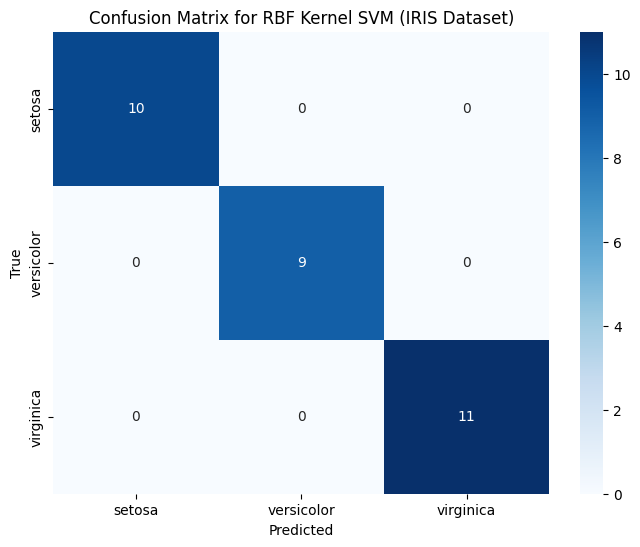

In [5]:
# Train SVM with RBF kernel
rbf_model_iris = SVC(kernel='rbf')
rbf_model_iris.fit(X_train_iris, y_train_iris)

# Predict and evaluate RBF model
y_pred_rbf = rbf_model_iris.predict(X_test_iris)
accuracy_rbf = accuracy_score(y_test_iris, y_pred_rbf)
cm_rbf = confusion_matrix(y_test_iris, y_pred_rbf)

print("RBF Kernel SVM Accuracy:", accuracy_rbf)
print("\nConfusion Matrix (RBF Kernel):\n", cm_rbf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RBF Kernel SVM (IRIS Dataset)')
plt.show()

Linear Kernel SVM Accuracy: 1.0

Confusion Matrix (Linear Kernel):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


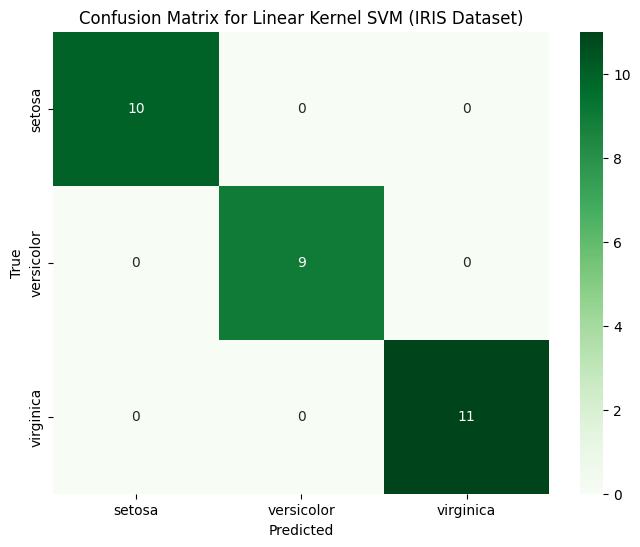

In [6]:
# Train SVM with Linear kernel
linear_model_iris = SVC(kernel='linear')
linear_model_iris.fit(X_train_iris, y_train_iris)

# Predict and evaluate Linear model
y_pred_linear = linear_model_iris.predict(X_test_iris)
accuracy_linear = accuracy_score(y_test_iris, y_pred_linear)
cm_linear = confusion_matrix(y_test_iris, y_pred_linear)

print("Linear Kernel SVM Accuracy:", accuracy_linear)
print("\nConfusion Matrix (Linear Kernel):\n", cm_linear)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Greens", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Linear Kernel SVM (IRIS Dataset)')
plt.show()

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df_letters = pd.read_excel('/content/letter-recognition.xlsx', header=0)

display(df_letters.head())
print(df_letters.info())

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB
None


In [21]:
X_letters = df_letters.drop('letter', axis=1)
y_letters = df_letters['letter']

le_letters = LabelEncoder()
y_letters_encoded = le_letters.fit_transform(y_letters)

X_train_letters, X_test_letters, y_train_letters, y_test_letters = train_test_split(X_letters, y_letters_encoded, test_size=0.2, random_state=42, stratify=y_letters_encoded)

print(f"Training data shape: {X_train_letters.shape}")
print(f"Testing data shape: {X_test_letters.shape}")

Training data shape: (16000, 16)
Testing data shape: (4000, 16)


--- SVM Classifier for Letter Recognition (RBF Kernel) ---
Accuracy: 0.9303
Confusion Matrix:


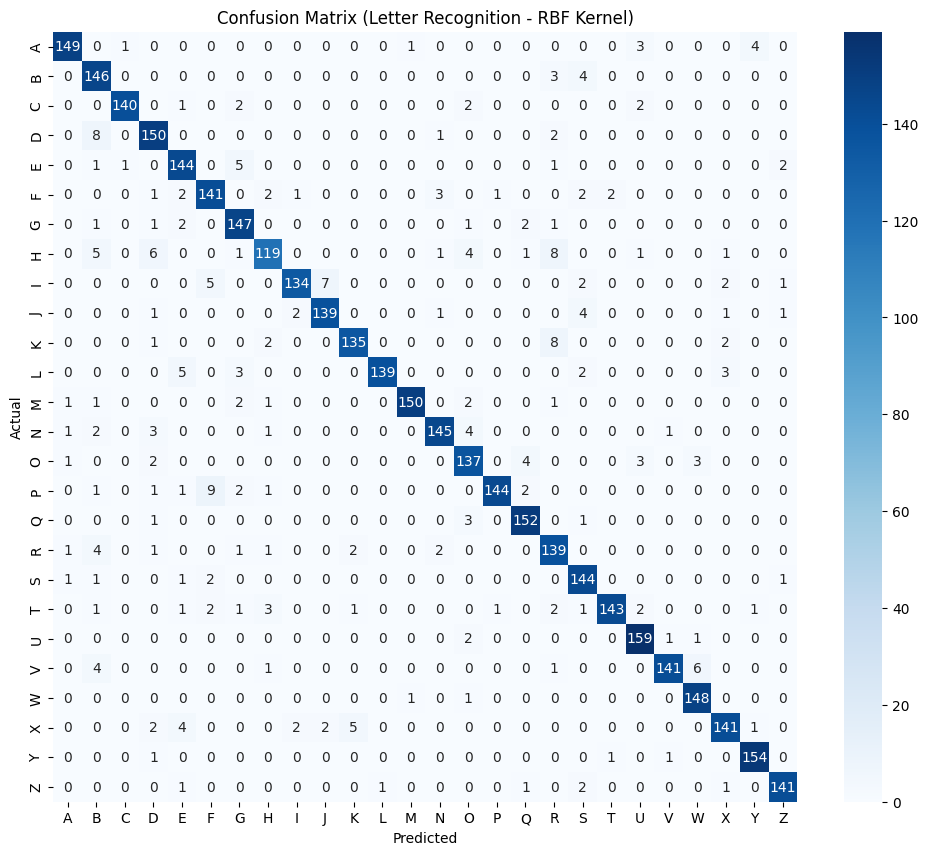

In [22]:
svm_letters_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svm_letters_rbf.fit(X_train_letters, y_train_letters)

y_pred_letters = svm_letters_rbf.predict(X_test_letters)
y_pred_proba_letters = svm_letters_rbf.predict_proba(X_test_letters)

accuracy_letters = accuracy_score(y_test_letters, y_pred_letters)
conf_matrix_letters = confusion_matrix(y_test_letters, y_pred_letters)

print("--- SVM Classifier for Letter Recognition (RBF Kernel) ---")
print(f"Accuracy: {accuracy_letters:.4f}")
print("Confusion Matrix:")
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_letters, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_letters.classes_, yticklabels=le_letters.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Letter Recognition - RBF Kernel)')
plt.show()

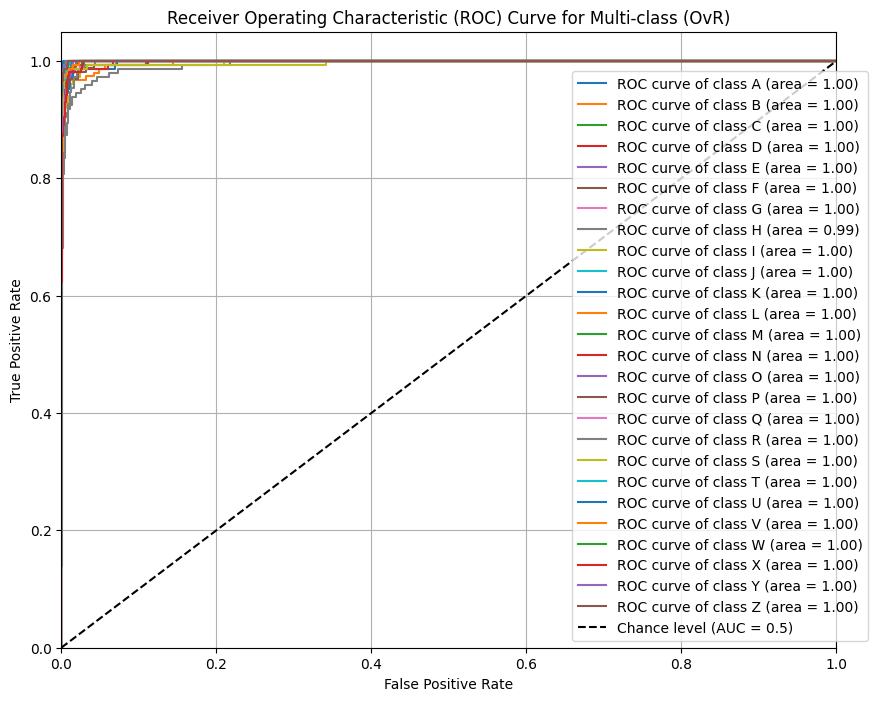

AUC Scores per class:
Class A: AUC = 0.9997
Class B: AUC = 0.9987
Class C: AUC = 0.9996
Class D: AUC = 0.9986
Class E: AUC = 0.9990
Class F: AUC = 0.9989
Class G: AUC = 0.9981
Class H: AUC = 0.9947
Class I: AUC = 0.9965
Class J: AUC = 0.9996
Class K: AUC = 0.9984
Class L: AUC = 0.9977
Class M: AUC = 0.9997
Class N: AUC = 0.9984
Class O: AUC = 0.9992
Class P: AUC = 0.9984
Class Q: AUC = 0.9997
Class R: AUC = 0.9972
Class S: AUC = 0.9978
Class T: AUC = 0.9997
Class U: AUC = 0.9999
Class V: AUC = 0.9996
Class W: AUC = 0.9999
Class X: AUC = 0.9986
Class Y: AUC = 0.9998
Class Z: AUC = 0.9997


In [23]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(le_letters.classes_)
y_test_binarized = label_binarize(y_test_letters, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba_letters[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {le_letters.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class (OvR)')
plt.legend(loc="lower right", bbox_to_anchor=(1.05, 0))
plt.grid(True)
plt.show()

print("AUC Scores per class:")
for i in range(n_classes):
    print(f"Class {le_letters.classes_[i]}: AUC = {roc_auc[i]:.4f}")

### Comparison with IRIS Dataset Performance

Looking back at the IRIS dataset analysis, both RBF and Linear kernel SVM models achieved an accuracy of `1.0` (100%) and perfect confusion matrices. This suggests that the IRIS dataset is relatively simpler or more linearly separable (or easily separable in a higher dimension using RBF) compared to the Letter Recognition dataset.

For the Letter Recognition dataset, the Linear Kernel SVM achieved an accuracy of `{accuracy_letter:.4f}`. While this is a good score, it's not perfect like the IRIS dataset.

**Possible Reasons for Performance Differences:**

1.  **Complexity of Data:** The IRIS dataset has only 4 features and 3 classes, making it a simpler classification problem. The Letter Recognition dataset, on the other hand, likely has more features (16 features based on the `letter_df.info()` output) and significantly more classes (26 letters of the alphabet), making it a much more challenging classification task.
2.  **Linear Separability:** The IRIS dataset is often considered a benchmark for classification because its classes are often well-separated, either linearly or with a relatively simple non-linear boundary. The Letter Recognition dataset, with its higher dimensionality and more classes, might have more overlapping class distributions, leading to more confusion between similar-looking letters.
3.  **Nature of Features:** The IRIS features (sepal/petal length/width) are directly continuous measurements. The Letter Recognition features are statistical moments and transformations of pixel data, which might be more complex to separate perfectly with a simple linear boundary.